# Detection de fraude avec arbre de decision



# 1. Chargement et première inspection des données

In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, auc
from sklearn.preprocessing import StandardScaler

import optuna
from sklearn.model_selection import RandomizedSearchCV

In [366]:
df = pd.read_csv('data/Fraud Detection Dataset.csv')

In [367]:
print(f"La taille du dataset est de {df.shape[0]} lignes et {df.shape[1]} colonnes")

La taille du dataset est de 51000 lignes et 12 colonnes


In [368]:
print("Les informations sur les données :")
df.info()

Les informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                      

On remarque déjà que:
- Toutes les colonnes n'ont pas la même taille, donc on a des valeurs manquantes que l'ont traitera plutard
- Il y a des varaibles categorielles

In [369]:
# visulisation des premières lignes du dataset
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [370]:
# Résumé des varaibles numériques
print("Résumé des variables numériques :")
df.describe().T

Résumé des variables numériques :


,count,mean,std,min,25%,50%,75%,max
User_ID,51000.0,3005.110176,1153.121107,1000.00,2007.0000,2996.0,4006.00,4999.0
Transaction_Amount,48480.0,2996.249784,5043.932555,5.03,1270.5525,2524.1,3787.24,49997.8
Time_of_Transaction,48448.0,11.488400,6.922954,0.00,5.0000,12.0,17.00,23.0
Previous_Fraudulent_Transactions,51000.0,1.995725,1.415150,0.00,1.0000,2.0,3.00,4.0
Account_Age,51000.0,60.033902,34.384131,1.00,30.0000,60.0,90.00,119.0
Number_of_Transactions_Last_24H,51000.0,7.495588,4.020080,1.00,4.0000,7.0,11.00,14.0
Fraudulent,51000.0,0.049216,0.216320,0.00,0.0000,0.0,0.00,1.0


> On remarque que les features n'ont pas la même plage de valeur donc les normalisera pour pouvoir utiliser le model de DecisionTreeClassifier

In [371]:
# vérification des valeurs manquantes
print("Vérification des valeurs manquantes :")
print(df.isnull().sum())

Vérification des valeurs manquantes :
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [372]:
# la cible 'Fraudulent' n'a pas de valeurs manquantes


In [373]:
# verification des doublons
print("Vérification des doublons :")
print(f"Nombre de doublons : {df.duplicated().sum()}")

Vérification des doublons :
Nombre de doublons : 881


# 2. Analyse exploratoire des données (EDA)

> comprendre les variables, leurs distributions, leurs relations et préparer les décisions de nettoyage.

##  Analyse univarié

###  Des variables numériques

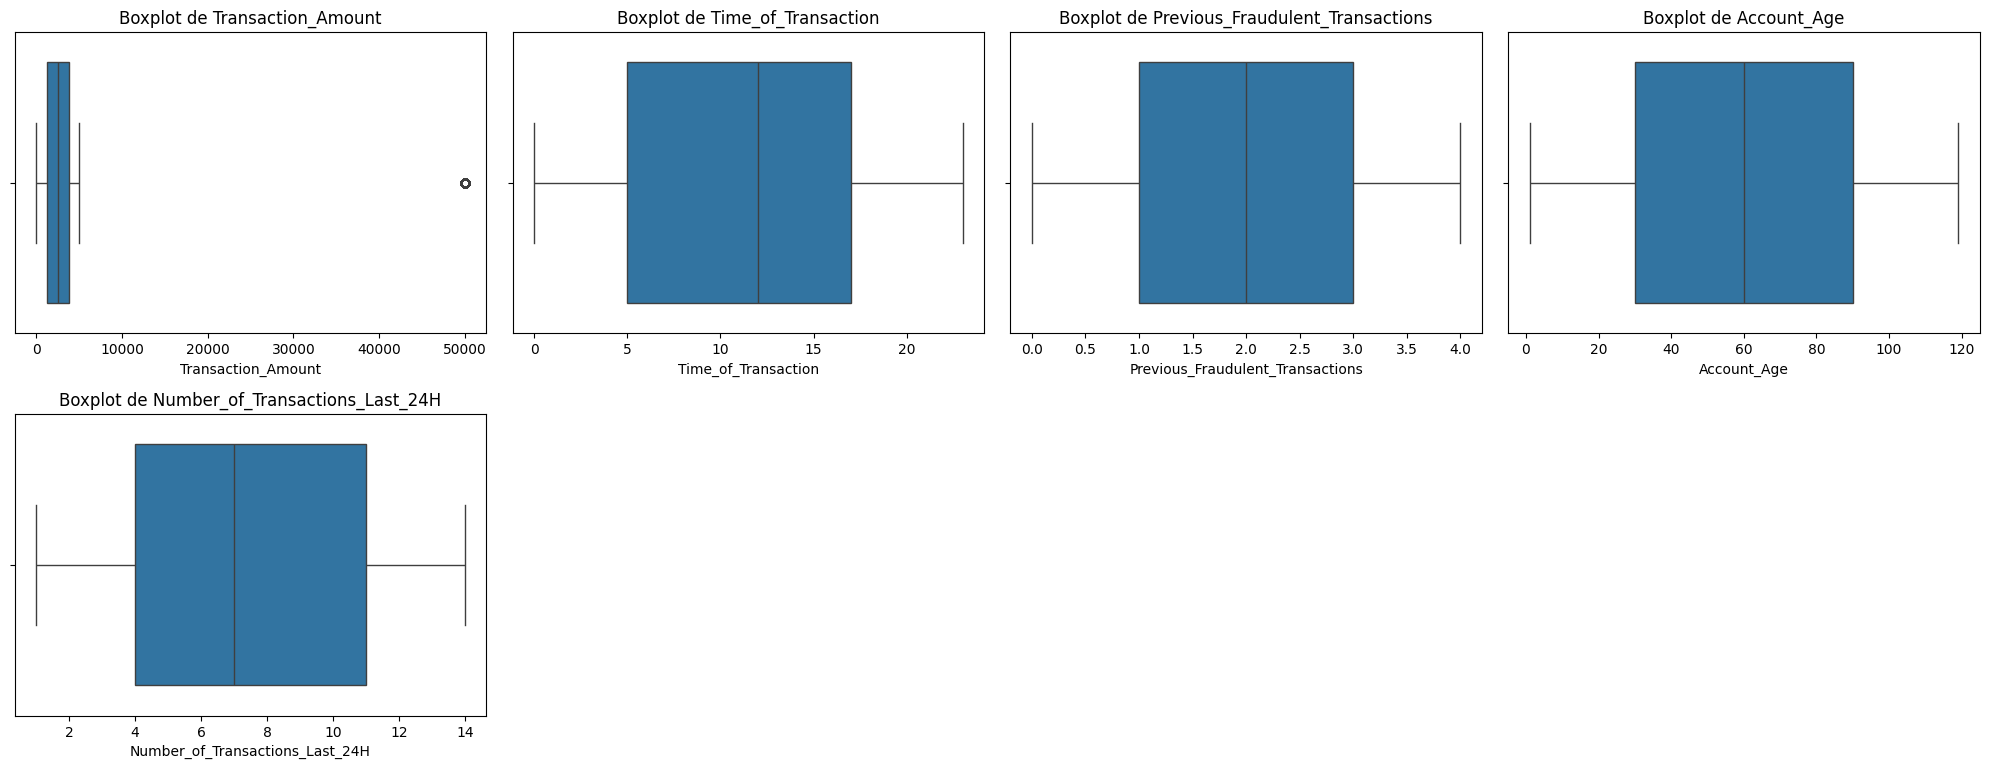

In [374]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Fraudulent')  # Exclure la variable cible
num_cols.remove('User_ID')  # Exclure l'identifiant de l'utilisateur

plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

In [375]:
# Nomnbre de transactions avec un montant supérieur à 40000 (les outliers)'
(df["Transaction_Amount"] > 40000).sum()

np.int64(508)

> On remarque que la colonne `Transaction_Amount` à des valeur qui s'eloigne fortement des autres mais sans contexte on ne peut pas la qualifié d'aberrantes 
Vu le nombre (508) je pense que ce ne soit pas des valeurs aberrantes

### Des variables categorielles

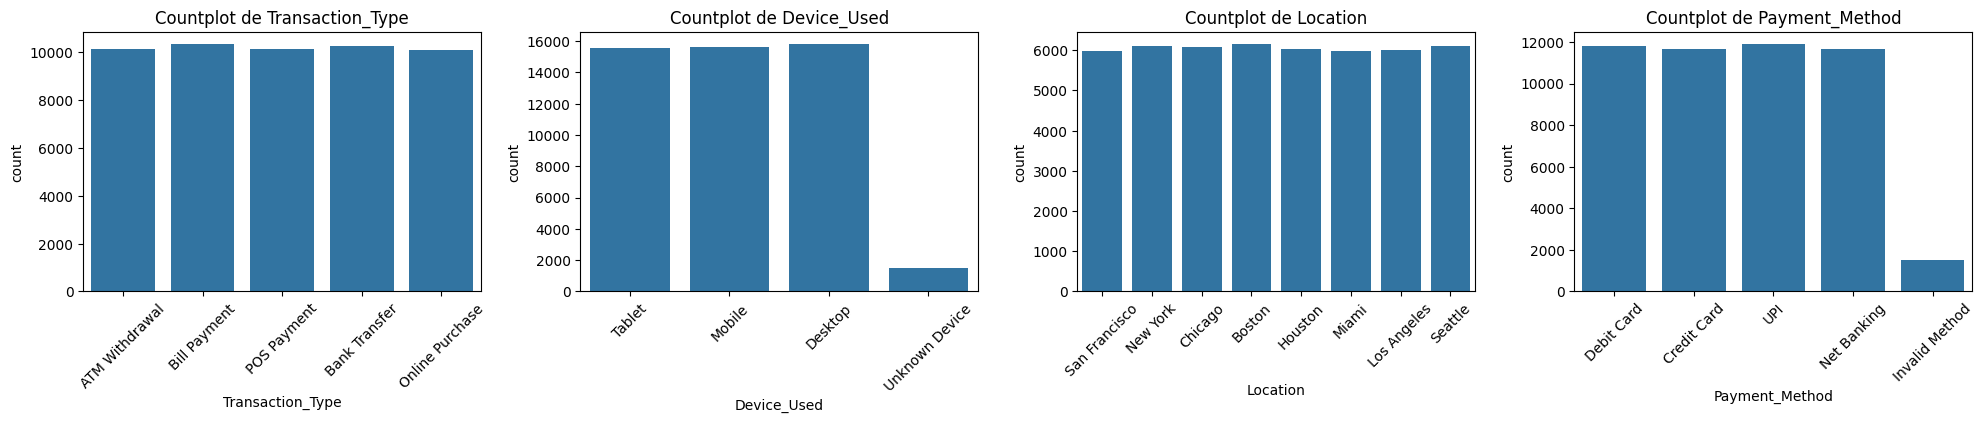

In [376]:
cat_cols = df.select_dtypes(include=['object']).columns.to_list()
cat_cols.remove('Transaction_ID')  # Exclure l'identifiant de transaction

plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 4, i + 1)
    sns.countplot(x=df[col])
    plt.title(f'Countplot de {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analyse bivariée

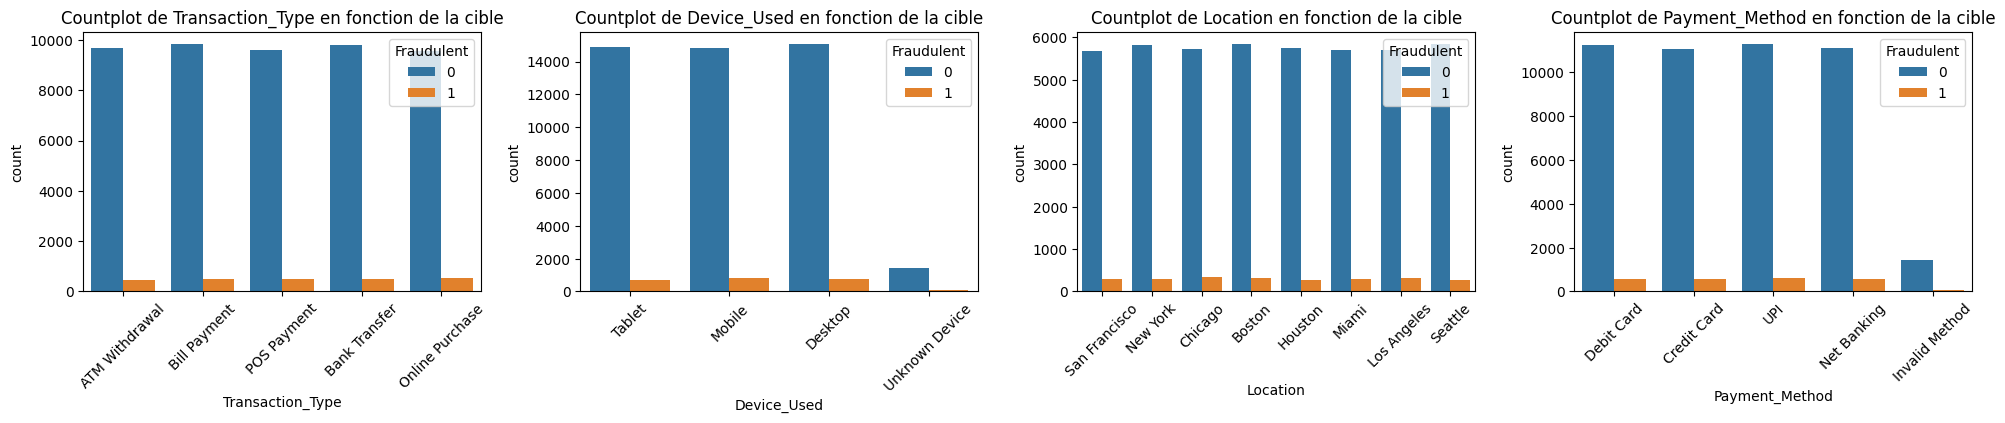

In [377]:
# analyse bivariée entre les variables catégorielles et la cible
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 4, i + 1)
    sns.countplot(x=df[col], hue=df['Fraudulent'])
    plt.title(f'Countplot de {col} en fonction de la cible')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> on remaque un éventuel déséquilibre de classes (beaucoup plus de 0 que de 1 dans la plupart des catégories).

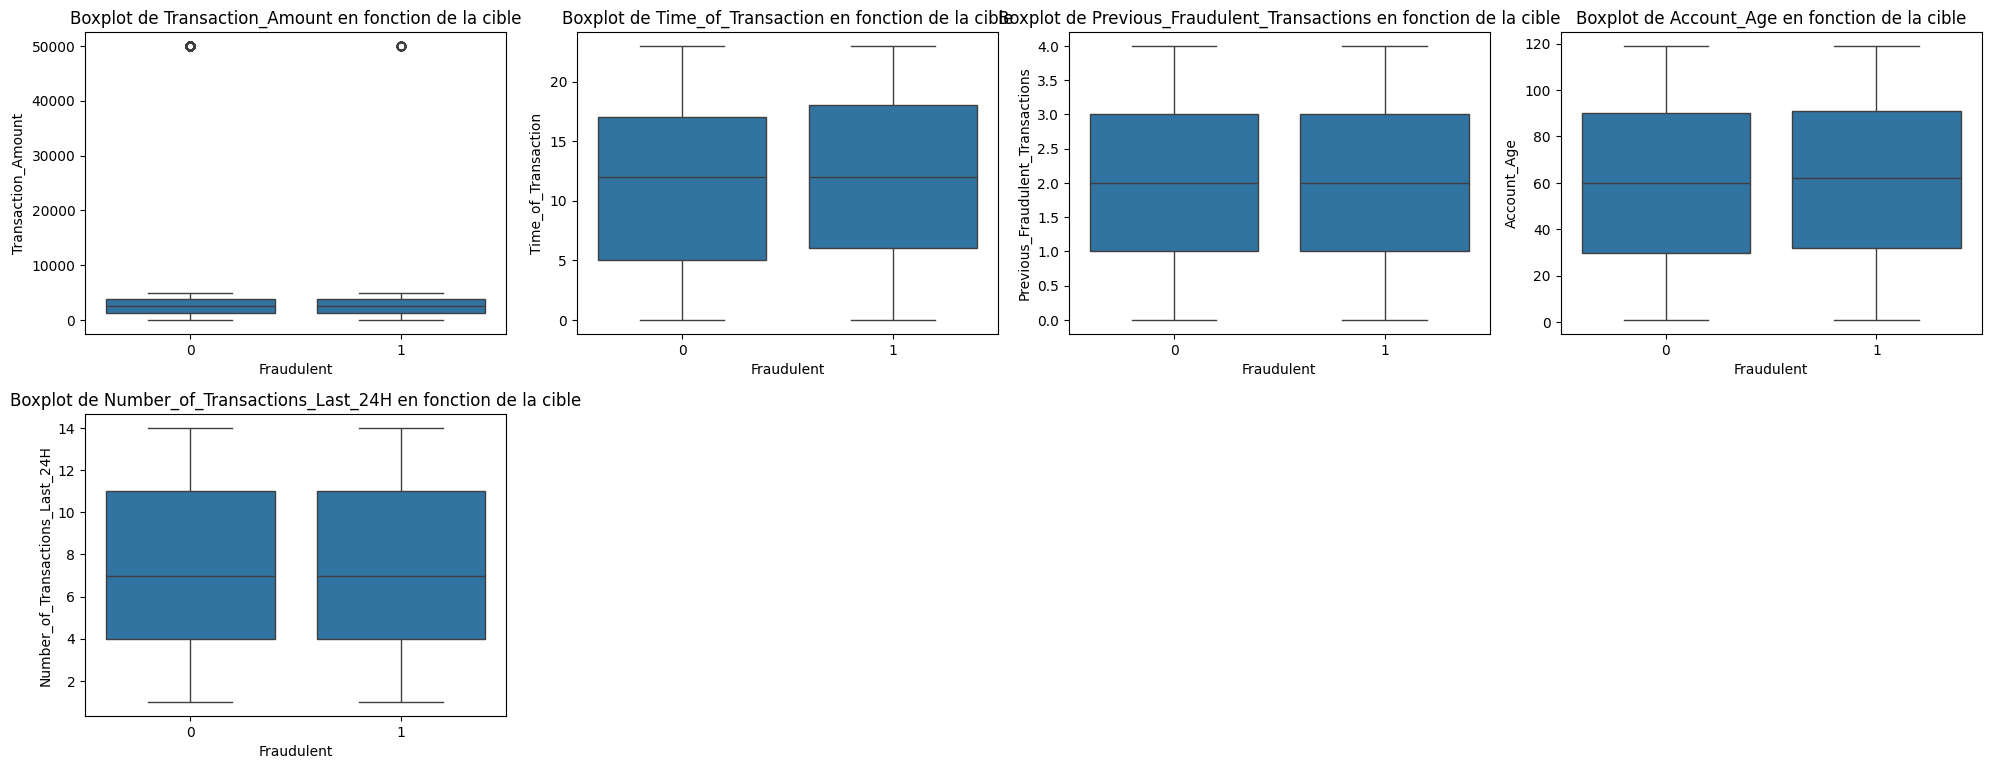

In [378]:
# analyse bivariée entre les variables numériques et la cible
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df['Fraudulent'], y=df[col])
    plt.title(f'Boxplot de {col} en fonction de la cible')
plt.tight_layout()
plt.show()

> On remarque que aucune de ces 6 variables n'est discriminante individuellement car les boxplot pour les deux classes de la cible sont relativement proche
> les boxplots se ressemble tous, il n'y a pas de réel difference entre fraude ou pas fraude

## Corrélations

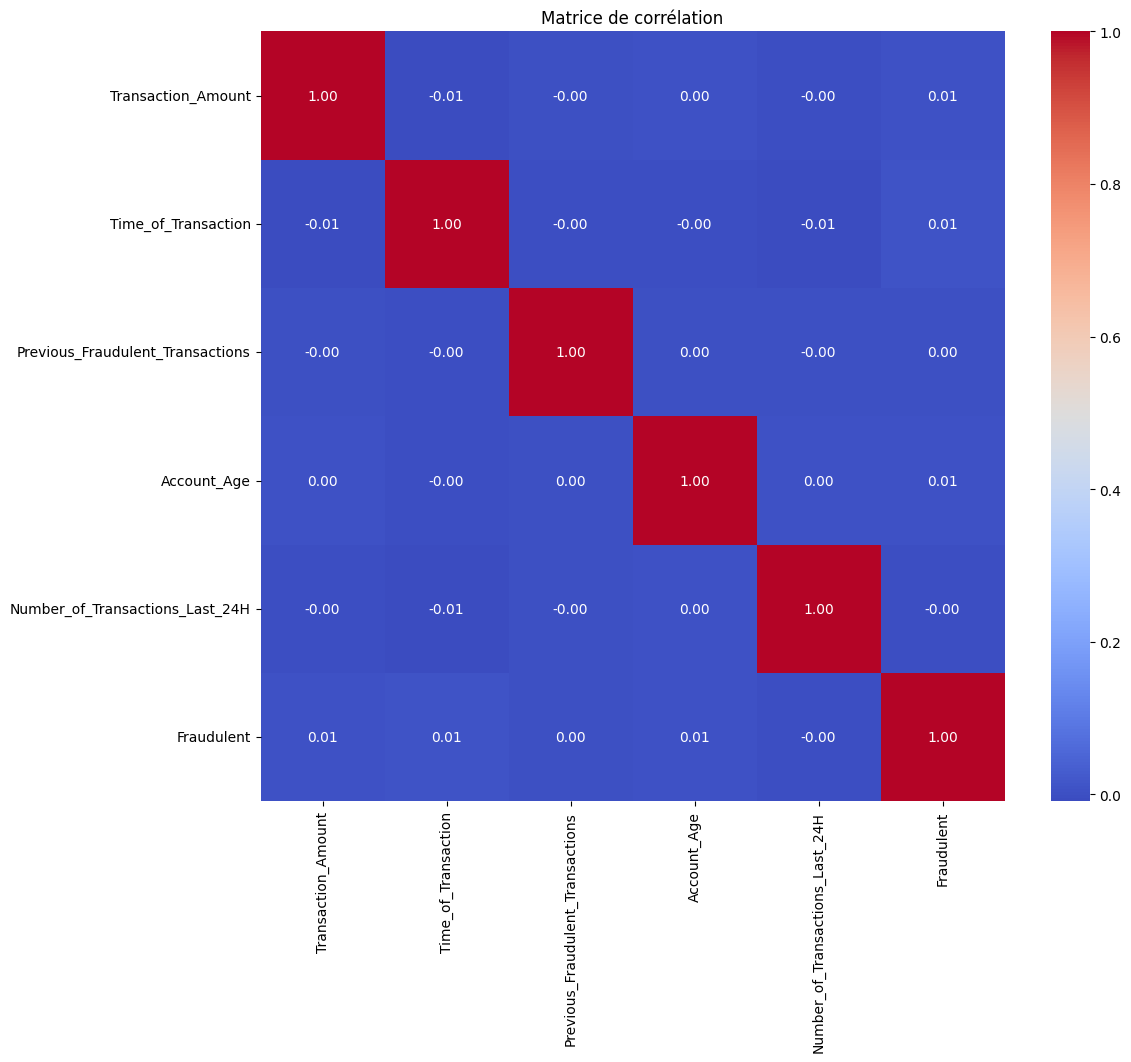

In [379]:
# matrice de corrélation entre les variables numériques et la cible
corr = df[num_cols + ['Fraudulent']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

> Le les variables ne sont pas corrélés donc il n'existe aucune relation linéaire

> Ca nous pousse à eviter les modeles linéaires qui se contenteront de predire que la classe majoritaire

## Déséquilibre des classes

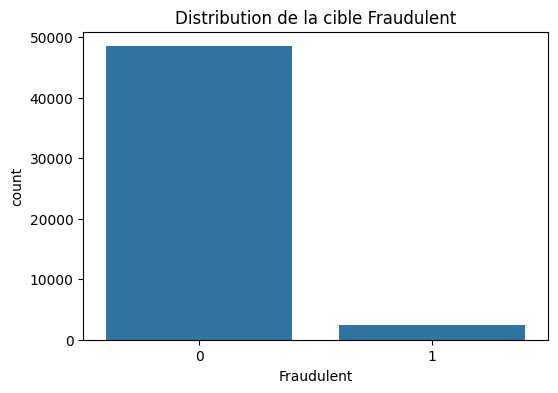

In [380]:
# distribution de la cible
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Fraudulent'])
plt.title('Distribution de la cible Fraudulent')
plt.show()

##### le target est totalement désiquilibré 
On est obligé:
- D'utiliser le paramètre `stratify` lors du train-test-split pour respecter les propostions
- D'utiliser d'autres metrics que l'Accuracy

# 3. Nettoyage et prétraitement des données

> Objectif : rendre les données exploitables par les algorithmes.

## Gestion des doublons

In [381]:
# supppresion des doublons
df = df.drop_duplicates()
print(f"Nombre de doublons après suppression : {df.duplicated().sum()}")
print(f"Taille du dataset après suppression des doublons : {df.shape[0]} lignes et {df.shape[1]} colonnes")

Nombre de doublons après suppression : 0
Taille du dataset après suppression des doublons : 50119 lignes et 12 colonnes


## Gestion des valeurs manquantes

In [382]:
# Imputation des valeurs manquantes pour les variables catégorielles
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Imputation des valeurs manquantes pour les variables numériques
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


print("Vérification des valeurs manquantes après imputation :")
print(df.isnull().sum())

Vérification des valeurs manquantes après imputation :
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


## Encodage des variables catégorielles

In [383]:
print(cat_cols)

['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']


> On remarque que les colonnes sont des variables nominal donc on a utiliser le onehot-encoding

In [384]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,Transaction_ID,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,...,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,Location_San Francisco,Location_Seattle,Payment_Method_Debit Card,Payment_Method_Invalid Method,Payment_Method_Net Banking,Payment_Method_UPI
0,T1,4174,1292.76,16.0,0,119,13,0,False,False,...,False,False,False,False,True,False,True,False,False,False
1,T2,4507,1554.58,13.0,4,79,3,0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,T3,1860,2395.02,12.0,3,115,9,0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,T4,2294,100.10,15.0,4,3,4,0,False,True,...,False,False,False,False,False,False,False,False,False,True
4,T5,2130,1490.50,19.0,2,57,7,0,False,False,...,False,False,False,False,True,False,False,False,False,False


## Normalisation des variables numériques 

In [385]:
# Normalisation des variables numériques

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded.head()

,Transaction_ID,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,...,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,Location_San Francisco,Location_Seattle,Payment_Method_Debit Card,Payment_Method_Invalid Method,Payment_Method_Net Banking,Payment_Method_UPI
0,T1,4174,-0.340960,0.664877,-1.410441,1.714659,1.369323,0,False,False,...,False,False,False,False,True,False,True,False,False,False
1,T2,4507,-0.287913,0.220229,1.415459,0.551605,-1.118384,0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,T3,1860,-0.117633,0.072013,0.708984,1.598353,0.374241,0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,T4,2294,-0.582603,0.516661,1.415459,-1.658197,-0.869613,0,False,True,...,False,False,False,False,False,False,False,False,False,True
4,T5,2130,-0.300896,1.109525,0.002509,-0.088074,-0.123301,0,False,False,...,False,False,False,False,True,False,False,False,False,False


## Feature engineering

In [386]:
# Calcul sur les valeurs originales (non normalisées) pour des ratios cohérents
df["amount_ratio"] = df["Transaction_Amount"] / df["Number_of_Transactions_Last_24H"]
df["fraud_ratio"] = df["Previous_Fraudulent_Transactions"] / df["Account_Age"]
df["montant_age_compte"] = df["Transaction_Amount"] / df["Account_Age"]

# Ajout à df_encoded
new_features = ["amount_ratio", "fraud_ratio", "montant_age_compte"]
for feat in new_features:
    df_encoded[feat] = df[feat]

# Normalisation des nouvelles features
df_encoded[new_features] = StandardScaler().fit_transform(df_encoded[new_features])

## Normalisation / standardisation des variables numériques 

In [387]:
X = df_encoded.drop(columns=["Transaction_ID", "User_ID", "Fraudulent"])
y = df_encoded['Fraudulent']

## Découpage en jeux d’entraînement, validation et test

In [388]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Le modèle de base
> Etablir une première mesure de performance, simple et interprétable.

In [389]:
# random_state pour la reproductibilité
baseline = DecisionTreeClassifier(random_state=42)

In [390]:
# Entrainement du model
baseline.fit(X_train, y_train)

# prediction sur le test
y_pred_proba = baseline.predict_proba(X_test)[:, 1]
y_pred_proba

array([0., 1., 1., ..., 1., 0., 0.], shape=(10024,))

In [391]:
# Evaluation du model
print(f"AUC score: {roc_auc_score(y_test, y_pred_proba)}")

AUC score: 0.49973663393265877


> On reamarque le AUC est environ 0.5 donc le model predict alátoirement sans l'argument class_weight='balanced'

In [392]:
# random_state pour la reproductibilité
baseline = DecisionTreeClassifier(random_state=42, class_weight='balanced')

In [393]:
# Entrainement du model
baseline.fit(X_train, y_train)

# prediction sur le test
y_pred_proba = baseline.predict_proba(X_test)[:, 1]
y_pred_proba

array([0., 0., 0., ..., 0., 0., 0.], shape=(10024,))

In [394]:
print(f"AUC score baseline (class_weight='balanced') : {roc_auc_score(y_test, y_pred_proba)}")

# Essai avec un arbre élagué pour éviter l'overfitting
pruned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)
pruned.fit(X_train, y_train)
y_proba_pruned = pruned.predict_proba(X_test)[:, 1]
print(f"AUC score arbre élagué (max_depth=5, min_samples_leaf=20) : {roc_auc_score(y_test, y_proba_pruned):.4f}")

AUC score baseline (class_weight='balanced') : 0.5024297780936042
AUC score arbre élagué (max_depth=5, min_samples_leaf=20) : 0.4893


On va essayer d'améliorer le model en tunant les hyperparametres

# 5. Optimisation des hyperparamètres

## Utilisation Randomized

In [395]:
# Grille de paramètres à tester avec Randomized.
params_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20, 50],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": ["balanced", None],
    "random_state": [42]
}

In [396]:
n_entrainement = 1
for param in params_grid:
    n_entrainement *= len(params_grid[param])

print(f"Avec GridSearchCV on aura: {n_entrainement} entrainement fois le nombre de fold defini")

Avec GridSearchCV on aura: 5040 entrainement fois le nombre de fold defini


> Avec RandomizedSearch on va fixer le nombre d'iteration à 200

In [397]:
model = DecisionTreeClassifier()

random_grid = RandomizedSearchCV(estimator=model, param_distributions=params_grid, n_iter=200, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)

random_grid.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END class_weight=balanced, criterion=gini, max_depth=5, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, random_state=42, splitter=random; total time=   0.1s
[CV] END class_weight=balanced, criterion=gini, max_depth=5, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, random_state=42, splitter=random; total time=   0.3s
[CV] END class_weight=balanced, criterion=gini, max_depth=5, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, random_state=42, splitter=random; total time=   0.3s
[CV] END class_weight=None, criterion=gini, max_depth=15, max_features=None, min_samples_leaf=20, min_samples_split=20, random_state=42, splitter=random; total time=   0.3s
[CV] END class_weight=None, criterion=entropy, max_depth=15, max_features=None, min_samples_leaf=50, min_samples_split=5, random_state=42, splitter=best; total time=   0.8s
[CV] END class_weight=None, criterion=gini, max_depth=15, max_

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [398]:
y_pred_proba= random_grid.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Meilleurs paramètres : {random_grid.best_params_}")
print(f"AUC : {auc:.2f}")

Meilleurs paramètres : {'splitter': 'random', 'random_state': 42, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': 15, 'criterion': 'entropy', 'class_weight': 'balanced'}
AUC : 0.47


### Utilisation d'optuna

In [399]:
# Fonction objectif pour Optuna : on maximise le AUC sur le jeu de test.
def objective(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "splitter": trial.suggest_categorical("splitter", ["best", "random"]),
        "max_depth": trial.suggest_categorical("max_depth", [3, 5, 7, 10, 15, 20, None]),
        "min_samples_split": trial.suggest_categorical("min_samples_split", [2, 5, 10, 20]),
        "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [1, 5, 10, 20, 50]),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
    }

    tree_model = DecisionTreeClassifier(**params)
    tree_model.fit(X_train, y_train)
    y_proba = tree_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    return auc

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True)

optuna_best_params = study.best_params
optuna_best_cv_auc = study.best_value

[I 2026-04-27 18:04:13,810] A new study created in memory with name: no-name-eb27a38d-fb68-4637-8db2-2c05cdf3eac9
Best trial: 0. Best value: 0.500282:   1%|          | 1/100 [00:00<00:13,  7.29it/s]

[I 2026-04-27 18:04:13,952] Trial 0 finished with value: 0.5002819879104865 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 50, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.5002819879104865.


Best trial: 1. Best value: 0.515844:   1%|          | 1/100 [00:00<00:13,  7.29it/s]

[I 2026-04-27 18:04:14,000] Trial 1 finished with value: 0.5158443154323151 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.5158443154323151.


Best trial: 4. Best value: 0.525085:   4%|▍         | 4/100 [00:00<00:19,  5.01it/s]

...

[I 2026-04-27 18:04:23,097] Trial 89 finished with value: 0.5143623359495426 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 27 with value: 0.5373802110035726.
[I 2026-04-27 18:04:23,209] Trial 90 finished with value: 0.5117074995802103 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': None}. Best is trial 27 with value: 0.5373802110035726.
[I 2026-04-27 18:04:23,254] Trial 91 finished with value: 0.5140524684796042 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 27 with value: 0.5373802110035726.
[I 2026-04-27 18:04:23,297] Trial 92 finished with value: 0.49547563698940766 and parameters: {'criterio

Best trial: 27. Best value: 0.53738:  97%|█████████▋| 97/100 [00:09<00:00, 14.92it/s]

[I 2026-04-27 18:04:23,371] Trial 93 finished with value: 0.5152317099980994 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 27 with value: 0.5373802110035726.
[I 2026-04-27 18:04:23,408] Trial 94 finished with value: 0.4843410517148802 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 27 with value: 0.5373802110035726.
[I 2026-04-27 18:04:23,457] Trial 95 finished with value: 0.4969164355961959 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 27 with value: 0.5373802110035726.
[I 2026-04-27 18:04:23,565] Trial 96 finished with value: 0.49733069179828043 and par

Best trial: 27. Best value: 0.53738: 100%|██████████| 100/100 [00:09<00:00, 10.03it/s]

[I 2026-04-27 18:04:23,627] Trial 97 finished with value: 0.5006168618555059 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 27 with value: 0.5373802110035726.
[I 2026-04-27 18:04:23,720] Trial 98 finished with value: 0.4864061609144325 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 50, 'max_features': 'log2', 'class_weight': None}. Best is trial 27 with value: 0.5373802110035726.
[I 2026-04-27 18:04:23,786] Trial 99 finished with value: 0.4985042935585661 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 27 with value: 0.5373802110035726.


In [400]:
optuna_model = DecisionTreeClassifier(**optuna_best_params)    
optuna_model.fit(X_train, y_train)
val_pred_optuna = optuna_model.predict(X_test)
val_proba_optuna = optuna_model.predict_proba(X_test)[:, 1]


print("Meilleurs parametres Optuna:")
print(optuna_best_params)
print(f"Meilleure AUC CV: {optuna_best_cv_auc:.4f}")

Meilleurs parametres Optuna:
{'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': None}
Meilleure AUC CV: 0.5374
